# Exploratory Data Analysis(Non-Temporal Dataset): TB Case Notifications (2015-2025)

**Dataset:** Tuberculosis case notifications from Cordillera Administrative Region (CAR), Philippines

**Years:** 2015-2025 (11 years)

**Focus:** Missing data patterns, temporal trends, patient demographics, and clinical outcomes

## 1. Setup and Data Loading

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Load all yearly data files
data_dir = Path('../dataset/non-temporal/yearly_raw')
years = range(2015, 2026)

dataframes = []

for year in years:
    file_path = data_dir / f'2015-2025-study-without-names_{year}.csv'
    if file_path.exists():
        # Skip first row (contains "Case Notification" header), use second row as actual header
        df = pd.read_csv(file_path, skiprows=1)
        df['Year'] = year  # Add year column for tracking
        dataframes.append(df)
        print(f"Loaded {year}: {len(df):,} rows")
    else:
        print(f"Warning: {file_path} not found")

# Combine all years
df_all = pd.concat(dataframes, ignore_index=True)
print(f"\nTotal combined dataset: {len(df_all):,} rows, {len(df_all.columns)} columns")

Loaded 2015: 684 rows
Loaded 2016: 609 rows
Loaded 2017: 629 rows
Loaded 2018: 663 rows
Loaded 2019: 716 rows
Loaded 2020: 571 rows
Loaded 2021: 540 rows
Loaded 2022: 902 rows
Loaded 2023: 1,088 rows
Loaded 2024: 1,316 rows
Loaded 2025: 1,221 rows

Total combined dataset: 8,939 rows, 29 columns


In [5]:
# Display basic information
print("Dataset Shape:", df_all.shape)
print("\nColumn Names:")
for i, col in enumerate(df_all.columns, 1):
    print(f"{i:2}. {col}")

Dataset Shape: (8939, 29)

Column Names:
 1. No.
 2. Type
 3. Validation Status
 4. Date of Screening
 5. Date of Diagnosis
 6. Date of Notification
 7. TB/TPT Case No.
 8. Birthdate
 9. Age
10. Sex
11. Brgy
12. City/Municipality
13. Province
14. Region
15. Screening/Diagnosing Health Facility
16. Treatment Health Facility
17. Source of Patient
18. Anatomical Site
19. Registration Group
20. Bacteriologic Status
21. Microscopy Result
22. Microscopy Release Date
23. RDT Result
24. RDT Release Date
25. Date Started Tx
26. Outcome/Status
27. Date of Outcome/Status
28. Date/Time Record was Created
29. Year


In [6]:
# Display first few rows
df_all.head(10)

,No.,Type,Validation Status,Date of Screening,Date of Diagnosis,Date of Notification,TB/TPT Case No.,Birthdate,Age,Sex,...,Bacteriologic Status,Microscopy Result,Microscopy Release Date,RDT Result,RDT Release Date,Date Started Tx,Outcome/Status,Date of Outcome/Status,Date/Time Record was Created,Year
0,1,DSTB,Validated,No Data,No Data,"January 06, 2015",15002001,No Data,53,M,...,Clinically-diagnosed TB,0,No Data,Not Detected,No Data,"January 07, 2015",TREATMENT COMPLETED,"June 23, 2015",No Data,2015
1,2,DSTB,Validated,No Data,No Data,"January 16, 2015",15002002,"January 06, 1967",48,F,...,Clinically-diagnosed TB,0,No Data,Not Detected,No Data,"January 07, 2015",TREATMENT COMPLETED,"June 23, 2015",No Data,2015
2,3,DSTB,Validated,No Data,No Data,"February 03, 2015",15002003,"September 29, 1969",46,M,...,Bacteriologically-confirmed TB,+n (),No Data,Not Detected,No Data,"February 04, 2015",CURED,"July 21, 2015",No Data,2015
3,4,DSTB,Validated,No Data,No Data,"March 04, 2015",15002004,"September 26, 1969",46,M,...,Clinically-diagnosed TB,0,No Data,Not Detected,No Data,"February 06, 2015",TREATMENT COMPLETED,"January 07, 2016",No Data,2015
4,5,DSTB,Validated,No Data,No Data,"March 13, 2015",15002005,"February 14, 2015",59,M,...,Bacteriologically-confirmed TB,1+,No Data,Not Detected,No Data,"March 14, 2015",CURED,"August 28, 2015",No Data,2015
5,6,DSTB,Validated,No Data,No Data,"March 27, 2015",15002006,"September 16, 1940",74,F,...,Clinically-diagnosed TB,0,No Data,Not Detected,No Data,"March 18, 2015",NOT EVALUATED,"May 04, 2015",No Data,2015
6,7,DSTB,Validated,No Data,No Data,"April 17, 2015",15002007,"February 10, 2014",1,F,...,Clinically-diagnosed TB,Not Done,No Data,Not Detected,No Data,"April 18, 2015",TREATMENT COMPLETED,"December 02, 2015",No Data,2015
7,8,DSTB,Validated,No Data,No Data,"May 07, 2015",15002008,"November 03, 1974",35,M,...,Bacteriologically-confirmed TB,2+,No Data,Not Detected,No Data,"January 06, 2015",CURED,"June 26, 2015",No Data,2015
8,9,DSTB,Validated,No Data,No Data,"May 12, 2015",15002009,"September 25, 1963",52,M,...,Bacteriologically-confirmed TB,1+,No Data,Not Detected,No Data,"May 12, 2015",CURED,"October 26, 2015",No Data,2015
9,10,DSTB,Validated,No Data,No Data,"May 21, 2015",15002010,No Data,76,M,...,Clinically-diagnosed TB,0,No Data,Not Detected,No Data,"May 22, 2015",DIED,"June 23, 2015",No Data,2015


In [7]:
# Display data types
df_all.dtypes

No.                                     object
Type                                    object
Validation Status                       object
Date of Screening                       object
Date of Diagnosis                       object
Date of Notification                    object
TB/TPT Case No.                         object
Birthdate                               object
Age                                     object
Sex                                     object
Brgy                                    object
City/Municipality                       object
Province                                object
Region                                  object
Screening/Diagnosing Health Facility    object
Treatment Health Facility               object
Source of Patient                       object
Anatomical Site                         object
Registration Group                      object
Bacteriologic Status                    object
Microscopy Result                       object
Microscopy Re

## 2. Data Cleaning and Preprocessing

In [8]:
# Create a copy for cleaning
df = df_all.copy()

# Replace "No Data" with NaN for better analysis
df = df.replace('No Data', np.nan)

print("Replaced 'No Data' with NaN")

Replaced 'No Data' with NaN


In [9]:
# Parse date columns
date_columns = [
    'Date of Screening',
    'Date of Diagnosis',
    'Date of Notification',
    'Birthdate',
    'Microscopy Release Date',
    'RDT Release Date',
    'Date Started Tx',
    'Date of Outcome/Status',
    'Date/Time Record was Created'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        # Mark January 1, 1970 as missing (likely default value)
        df.loc[df[col] == '1970-01-01', col] = pd.NaT
        
print("Date columns parsed")

Date columns parsed


In [10]:
# Clean Age column (some entries might be birth years)
df['Age_Numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Flag suspicious ages (< 0 or > 120)
df['Age_Valid'] = df['Age_Numeric'].between(0, 120)

print(f"Valid ages: {df['Age_Valid'].sum():,}")
print(f"Invalid/missing ages: {(~df['Age_Valid']).sum():,}")

Valid ages: 7,389
Invalid/missing ages: 1,550


## 3. Missing Data Analysis

In [11]:
# Calculate missing data percentage for each column
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})

missing_stats = missing_stats.sort_values('Missing_Percentage', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)

print("Missing Data Summary:\n")
print(missing_stats.to_string())

Missing Data Summary:

                                  Column  Missing_Count  Missing_Percentage       Data_Type
0                Microscopy Release Date           7788               87.12  datetime64[ns]
1                       RDT Release Date           6112               68.37  datetime64[ns]
2                      Date of Diagnosis           5507               61.61  datetime64[ns]
3           Date/Time Record was Created           4284               47.92  datetime64[ns]
4                      Microscopy Result           4203               47.02          object
5                              Birthdate           1765               19.74  datetime64[ns]
6                      Date of Screening           1603               17.93  datetime64[ns]
7                            Age_Numeric           1550               17.34         float64
8                   Date of Notification           1550               17.34  datetime64[ns]
9              Treatment Health Facility           1545  

In [12]:
# Create outputs directory for images
import os
img_dir = Path('eda_outputs/images')
img_dir.mkdir(parents=True, exist_ok=True)
print(f"Image directory created: {img_dir}")

Image directory created: outputs/images


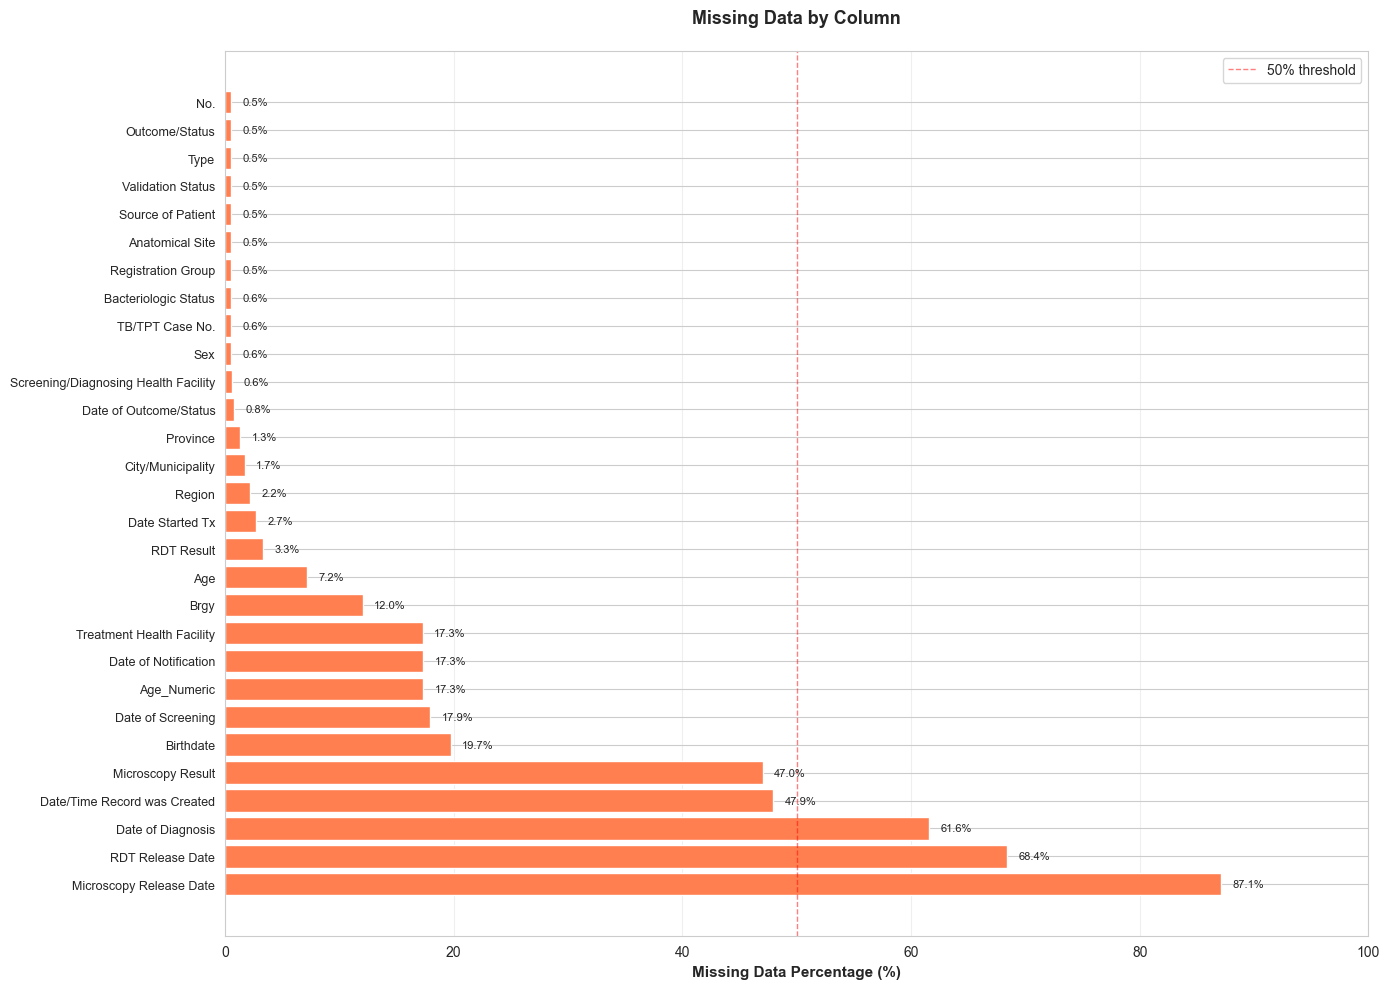

Saved: missing_data_by_column.png


In [13]:
# Visualize missing data patterns
fig, ax = plt.subplots(figsize=(14, 10))

# Filter columns with any missing data
cols_with_missing = missing_stats[missing_stats['Missing_Percentage'] > 0]['Column'].tolist()

if cols_with_missing:
    missing_pct = missing_stats[missing_stats['Missing_Percentage'] > 0].set_index('Column')['Missing_Percentage']
    
    bars = ax.barh(range(len(missing_pct)), missing_pct.values, color='coral')
    ax.set_yticks(range(len(missing_pct)))
    ax.set_yticklabels(missing_pct.index, fontsize=9)
    ax.set_xlabel('Missing Data Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_title('Missing Data by Column', fontsize=13, fontweight='bold', pad=20)
    ax.set_xlim(0, 100)
    
    # Add percentage labels
    for i, (bar, val) in enumerate(zip(bars, missing_pct.values)):
        ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)
    
    ax.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=1, label='50% threshold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
plt.tight_layout()
plt.savefig('eda_outputs/images/missing_data_by_column.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: missing_data_by_column.png")

In [14]:
# Missing data by year
key_columns = ['Date of Screening', 'Date of Diagnosis', 'Birthdate', 'Brgy', 
               'Microscopy Result', 'RDT Result', 'Date Started Tx', 'Outcome/Status']

missing_by_year = pd.DataFrame()

for col in key_columns:
    if col in df.columns:
        missing_by_year[col] = df.groupby('Year')[col].apply(lambda x: (x.isnull().sum() / len(x) * 100).round(2))

print("Missing Data Percentage by Year:\n")
print(missing_by_year.to_string())

Missing Data Percentage by Year:

      Date of Screening  Date of Diagnosis  Birthdate   Brgy  Microscopy Result  RDT Result  Date Started Tx  Outcome/Status
Year                                                                                                                        
2015              97.51              99.85      13.01  66.52              20.76        0.44             0.88            0.44
2016              81.44              99.84       8.05  29.56              18.72        0.49             0.99            0.49
2017              51.35              99.84       7.95  24.80               3.18        0.48             0.64            0.48
2018               6.49              98.49       3.92   9.65              11.46        0.45             0.60            0.45
2019               3.77              98.32       1.26  11.45              27.37        0.42             0.56            0.42
2020               0.70              96.32       1.05   7.53              48.34        0.53

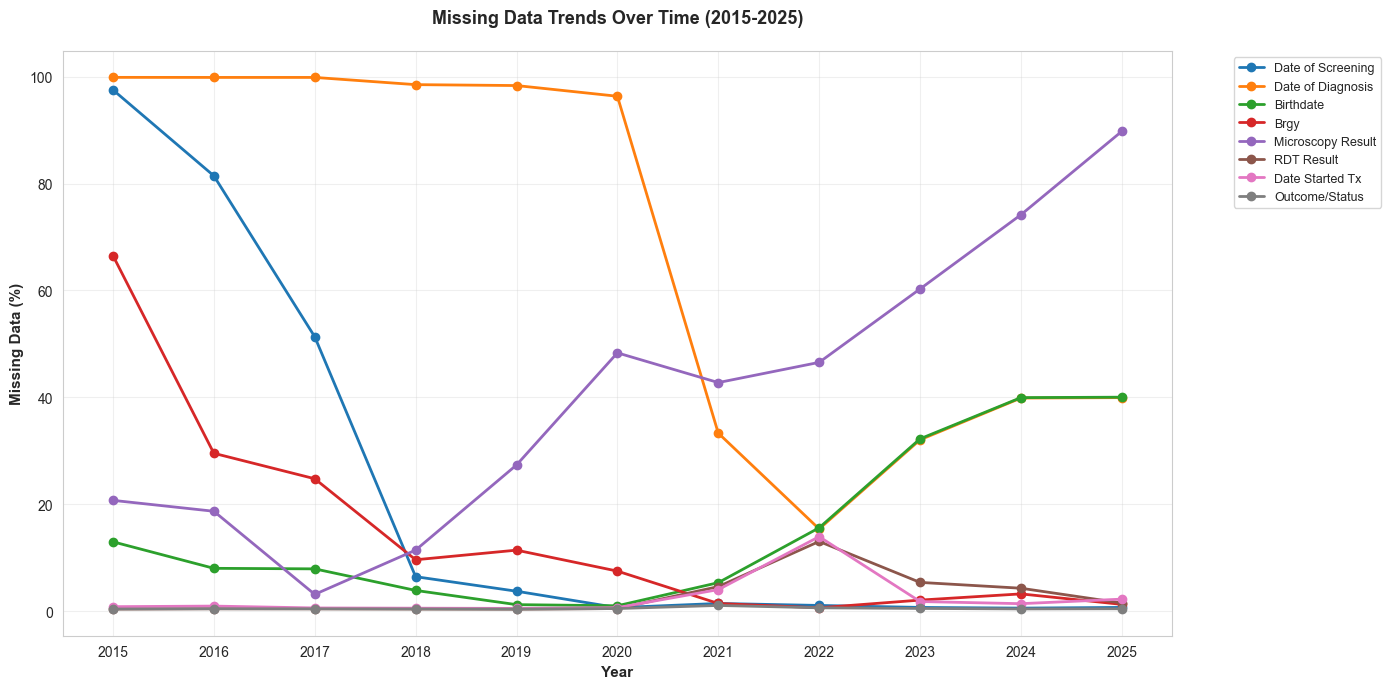

Saved: missing_data_trends.png


In [15]:
# Visualize missing data trends over time
fig, ax = plt.subplots(figsize=(14, 7))

for col in missing_by_year.columns:
    ax.plot(missing_by_year.index, missing_by_year[col], marker='o', label=col, linewidth=2)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Missing Data (%)', fontsize=11, fontweight='bold')
ax.set_title('Missing Data Trends Over Time (2015-2025)', fontsize=13, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(missing_by_year.index)

plt.tight_layout()
plt.savefig('eda_outputs/images/missing_data_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: missing_data_trends.png")

In [16]:
# Analyze completeness of critical fields
critical_fields = ['Age', 'Sex', 'Date of Notification', 'Anatomical Site', 
                   'Registration Group', 'Bacteriologic Status', 'Outcome/Status']

complete_records = df[critical_fields].notnull().all(axis=1).sum()
total_records = len(df)

print(f"Records with ALL critical fields complete: {complete_records:,} ({complete_records/total_records*100:.1f}%)")
print(f"Records with ANY missing critical field: {total_records - complete_records:,} ({(total_records - complete_records)/total_records*100:.1f}%)")

Records with ALL critical fields complete: 7,388 (82.6%)
Records with ANY missing critical field: 1,551 (17.4%)


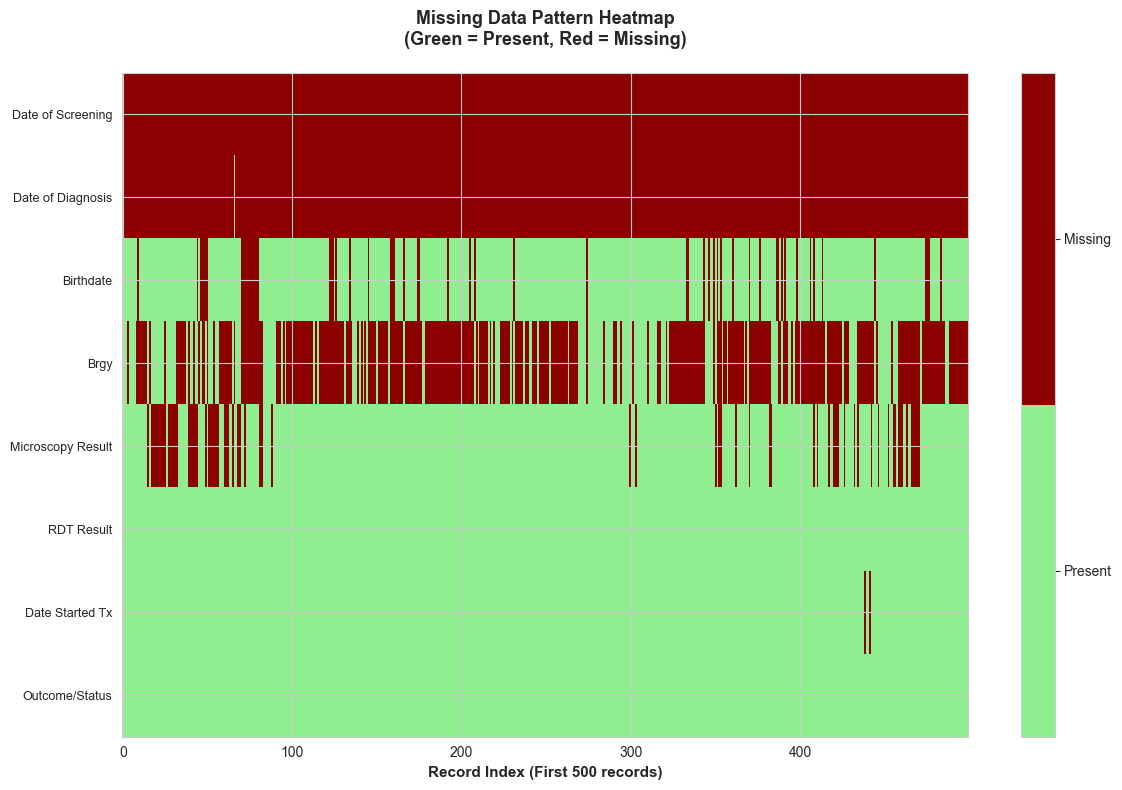

In [17]:
# Missing data heatmap for a sample
import matplotlib.colors as mcolors

# Sample data for visualization (first 500 rows, key columns)
sample_df = df[key_columns + ['Year']].head(500)

fig, ax = plt.subplots(figsize=(12, 8))

# Create binary matrix (1 = missing, 0 = present)
missing_matrix = sample_df[key_columns].isnull().astype(int)

# Create heatmap
cmap = mcolors.ListedColormap(['lightgreen', 'darkred'])
im = ax.imshow(missing_matrix.T, cmap=cmap, aspect='auto', interpolation='nearest')

ax.set_yticks(range(len(key_columns)))
ax.set_yticklabels(key_columns, fontsize=9)
ax.set_xlabel('Record Index (First 500 records)', fontsize=11, fontweight='bold')
ax.set_title('Missing Data Pattern Heatmap\n(Green = Present, Red = Missing)', 
             fontsize=13, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['Present', 'Missing'])

plt.tight_layout()
plt.show()

## 4. Temporal Analysis

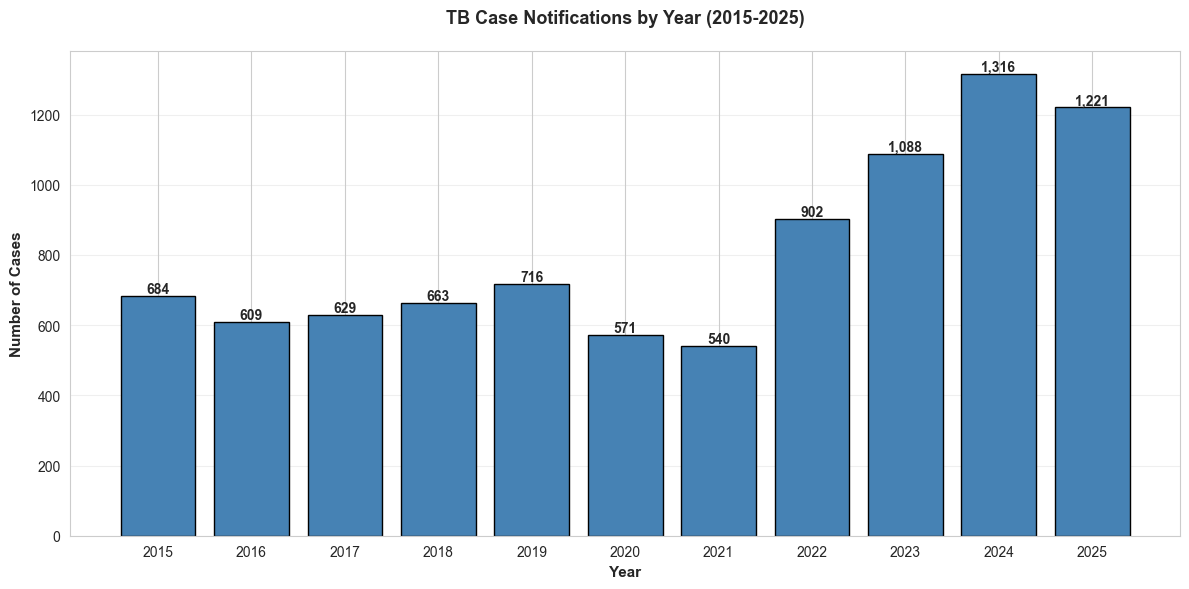


Yearly Case Counts:
 Year  Case_Count
 2015         684
 2016         609
 2017         629
 2018         663
 2019         716
 2020         571
 2021         540
 2022         902
 2023        1088
 2024        1316
 2025        1221
Saved: yearly_case_counts.png


In [18]:
# Case counts by year
yearly_counts = df.groupby('Year').size().reset_index(name='Case_Count')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(yearly_counts['Year'], yearly_counts['Case_Count'], color='steelblue', edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
ax.set_title('TB Case Notifications by Year (2015-2025)', fontsize=13, fontweight='bold', pad=20)
ax.set_xticks(yearly_counts['Year'])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_outputs/images/yearly_case_counts.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nYearly Case Counts:")
print(yearly_counts.to_string(index=False))
print("Saved: yearly_case_counts.png")

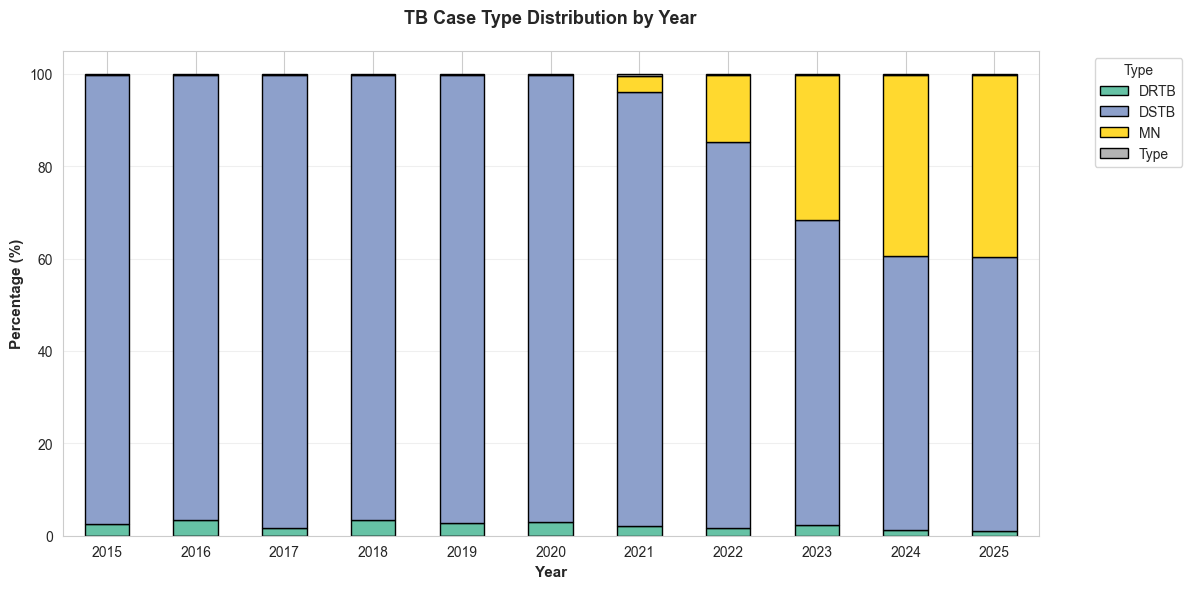

In [19]:
# Case type distribution over years
if 'Type' in df.columns:
    type_by_year = pd.crosstab(df['Year'], df['Type'], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    type_by_year.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')
    
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_title('TB Case Type Distribution by Year', fontsize=13, fontweight='bold', pad=20)
    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

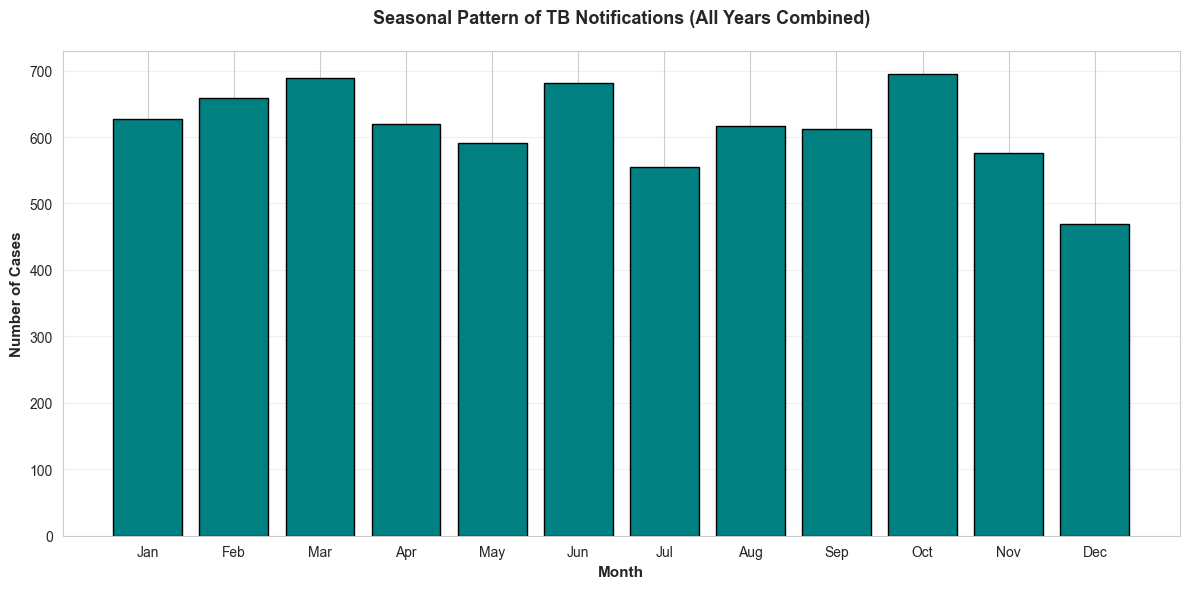

In [20]:
# Monthly notification patterns (aggregated across all years)
if 'Date of Notification' in df.columns:
    df['Notification_Month'] = df['Date of Notification'].dt.month
    
    monthly_counts = df['Notification_Month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.bar(monthly_counts.index, monthly_counts.values, color='teal', edgecolor='black')
    
    ax.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
    ax.set_title('Seasonal Pattern of TB Notifications (All Years Combined)', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Demographic Analysis

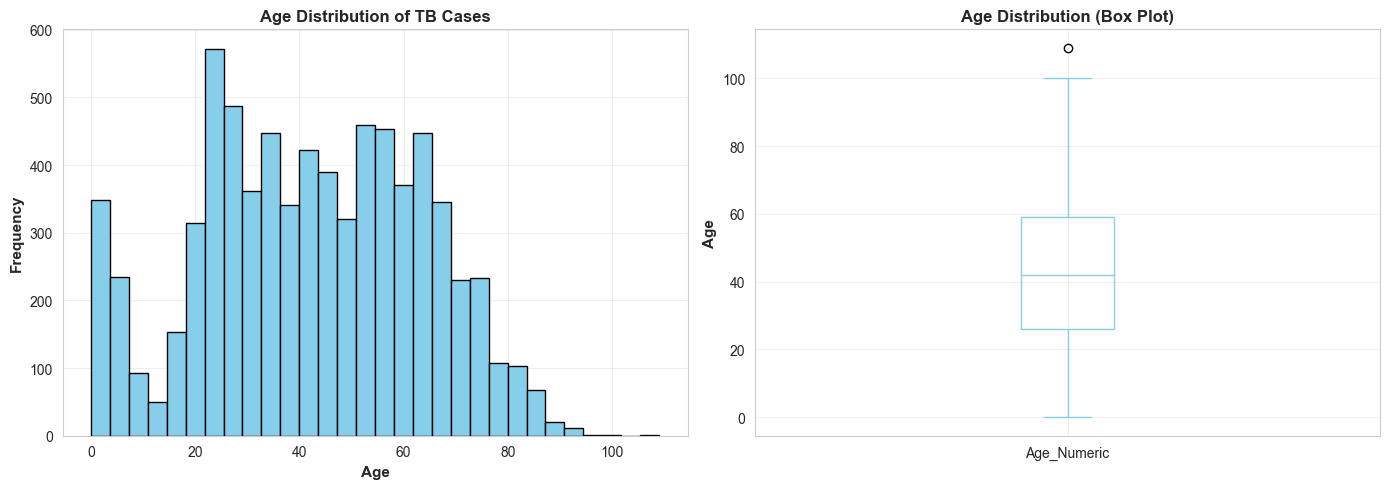


Age Statistics:
count    7389.000000
mean       42.290819
std        21.218663
min         0.000000
25%        26.000000
50%        42.000000
75%        59.000000
max       109.000000
Name: Age_Numeric, dtype: float64
Saved: age_distribution.png


In [21]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df[df['Age_Valid']]['Age_Numeric'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Age', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Age Distribution of TB Cases', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Box plot
df[df['Age_Valid']]['Age_Numeric'].plot(kind='box', ax=axes[1], color='skyblue')
axes[1].set_ylabel('Age', fontsize=11, fontweight='bold')
axes[1].set_title('Age Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_outputs/images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print("\nAge Statistics:")
print(df[df['Age_Valid']]['Age_Numeric'].describe())
print("Saved: age_distribution.png")

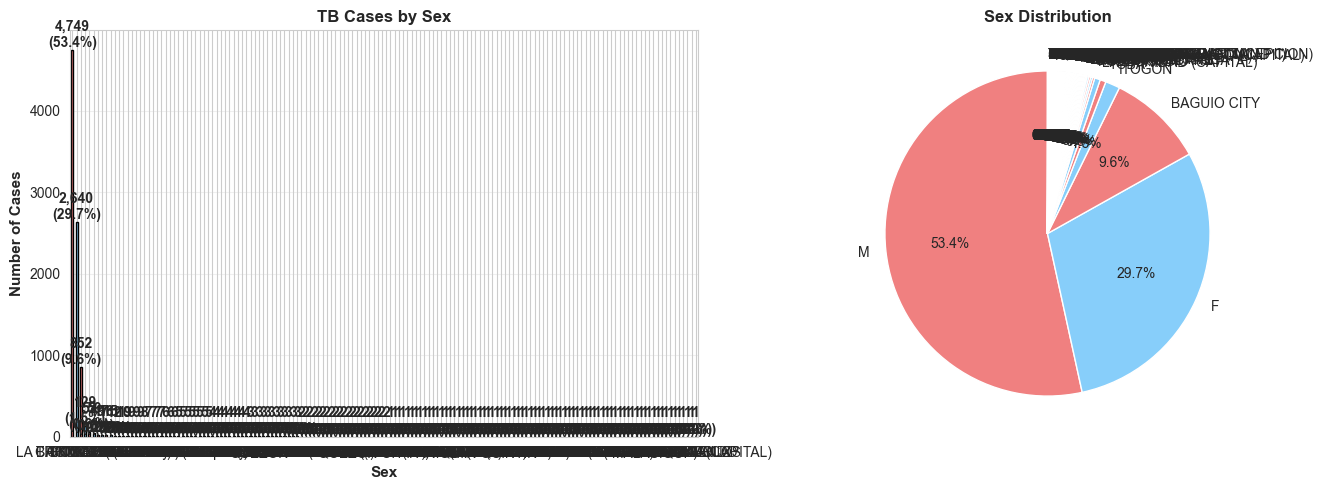

Saved: sex_distribution.png


In [22]:
# Sex distribution
if 'Sex' in df.columns:
    sex_counts = df['Sex'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    sex_counts.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightskyblue'], edgecolor='black')
    axes[0].set_xlabel('Sex', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
    axes[0].set_title('TB Cases by Sex', fontsize=12, fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add count labels
    for i, v in enumerate(sex_counts.values):
        axes[0].text(i, v, f'{v:,}\n({v/sex_counts.sum()*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    sex_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                    colors=['lightcoral', 'lightskyblue'], startangle=90)
    axes[1].set_ylabel('')
    axes[1].set_title('Sex Distribution', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('eda_outputs/images/sex_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: sex_distribution.png")

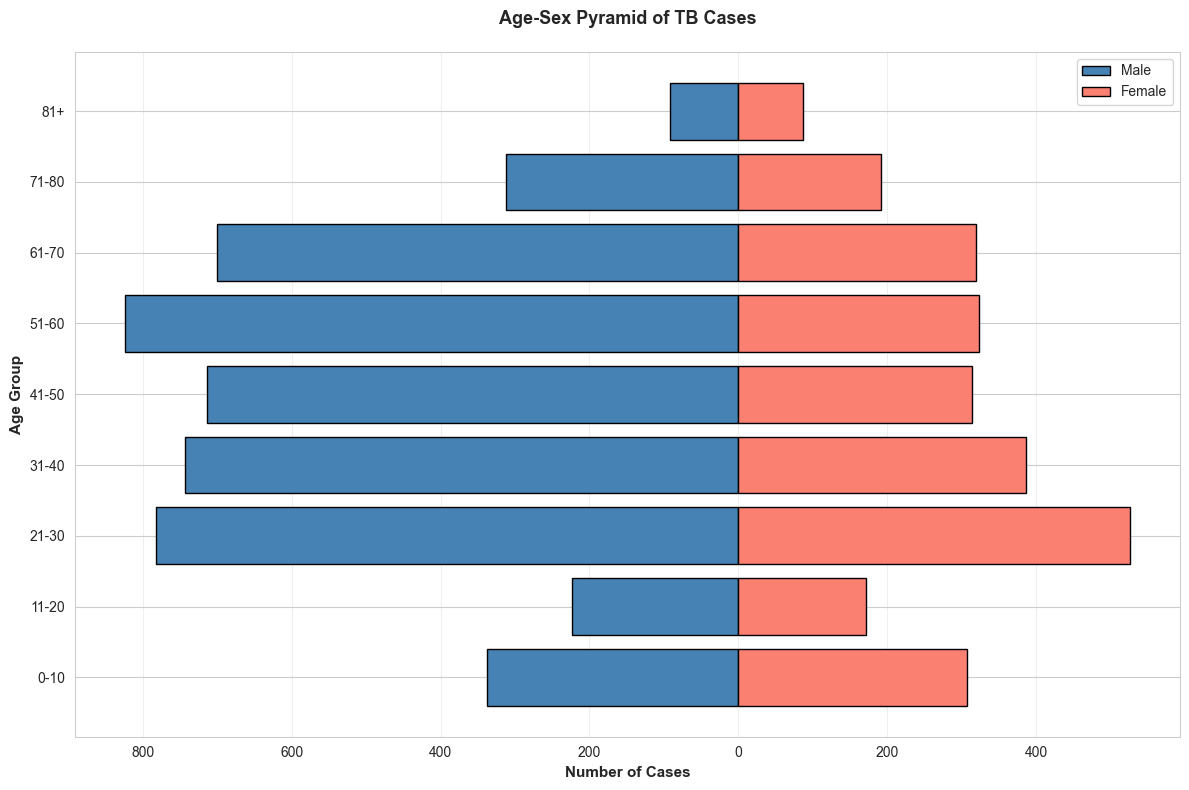

Saved: age_sex_pyramid.png


In [23]:
# Age-Sex pyramid
if 'Sex' in df.columns:
    # Create age groups
    df_valid_age = df[df['Age_Valid']].copy()
    df_valid_age['Age_Group'] = pd.cut(df_valid_age['Age_Numeric'], 
                                        bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 120],
                                        labels=['0-10', '11-20', '21-30', '31-40', '41-50', 
                                               '51-60', '61-70', '71-80', '81+'])
    
    # Count by age group and sex
    pyramid_data = df_valid_age.groupby(['Age_Group', 'Sex']).size().unstack(fill_value=0)
    
    if 'M' in pyramid_data.columns and 'F' in pyramid_data.columns:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Male (left side, negative values)
        ax.barh(pyramid_data.index, -pyramid_data['M'], color='steelblue', label='Male', edgecolor='black')
        # Female (right side, positive values)
        ax.barh(pyramid_data.index, pyramid_data['F'], color='salmon', label='Female', edgecolor='black')
        
        # Formatting
        ax.set_xlabel('Number of Cases', fontsize=11, fontweight='bold')
        ax.set_ylabel('Age Group', fontsize=11, fontweight='bold')
        ax.set_title('Age-Sex Pyramid of TB Cases', fontsize=13, fontweight='bold', pad=20)
        ax.legend()
        
        # Make x-axis labels absolute values
        ticks = ax.get_xticks()
        ax.set_xticklabels([f'{abs(int(x)):,}' for x in ticks])
        
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('eda_outputs/images/age_sex_pyramid.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: age_sex_pyramid.png")

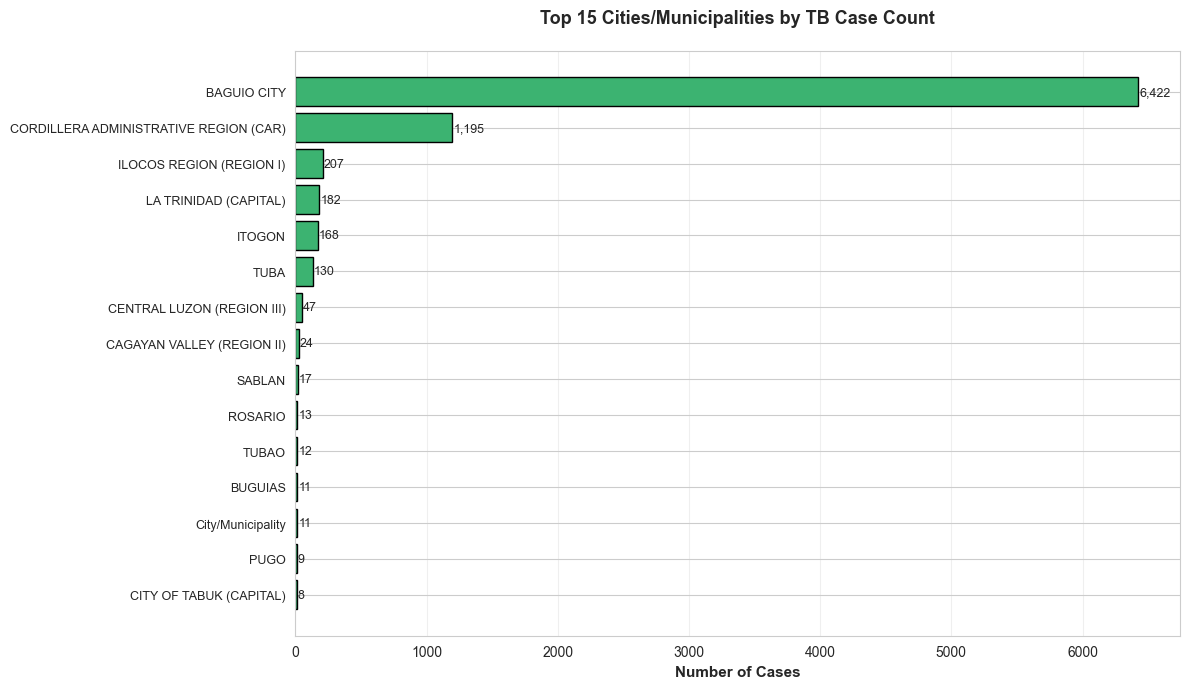

In [24]:
# Geographic distribution (top municipalities)
if 'City/Municipality' in df.columns:
    city_counts = df['City/Municipality'].value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bars = ax.barh(range(len(city_counts)), city_counts.values, color='mediumseagreen', edgecolor='black')
    ax.set_yticks(range(len(city_counts)))
    ax.set_yticklabels(city_counts.index, fontsize=9)
    ax.set_xlabel('Number of Cases', fontsize=11, fontweight='bold')
    ax.set_title('Top 15 Cities/Municipalities by TB Case Count', fontsize=13, fontweight='bold', pad=20)
    ax.invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(city_counts.values):
        ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
    
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Clinical Characteristics

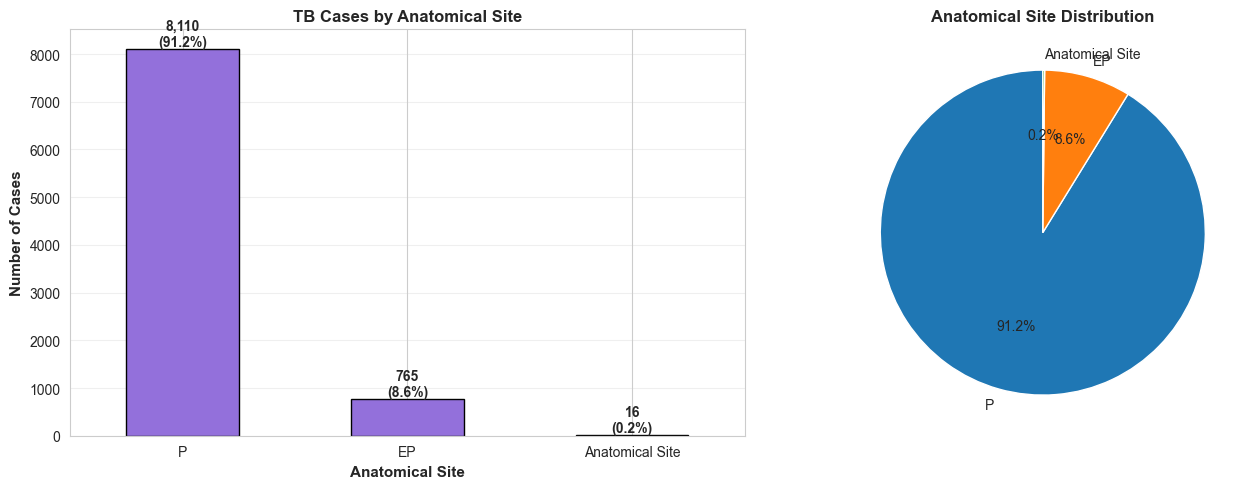

In [25]:
# Anatomical site distribution
if 'Anatomical Site' in df.columns:
    anatomical_counts = df['Anatomical Site'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    anatomical_counts.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='black')
    axes[0].set_xlabel('Anatomical Site', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
    axes[0].set_title('TB Cases by Anatomical Site', fontsize=12, fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(anatomical_counts.values):
        axes[0].text(i, v, f'{v:,}\n({v/anatomical_counts.sum()*100:.1f}%)', 
                    ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    anatomical_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_ylabel('')
    axes[1].set_title('Anatomical Site Distribution', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

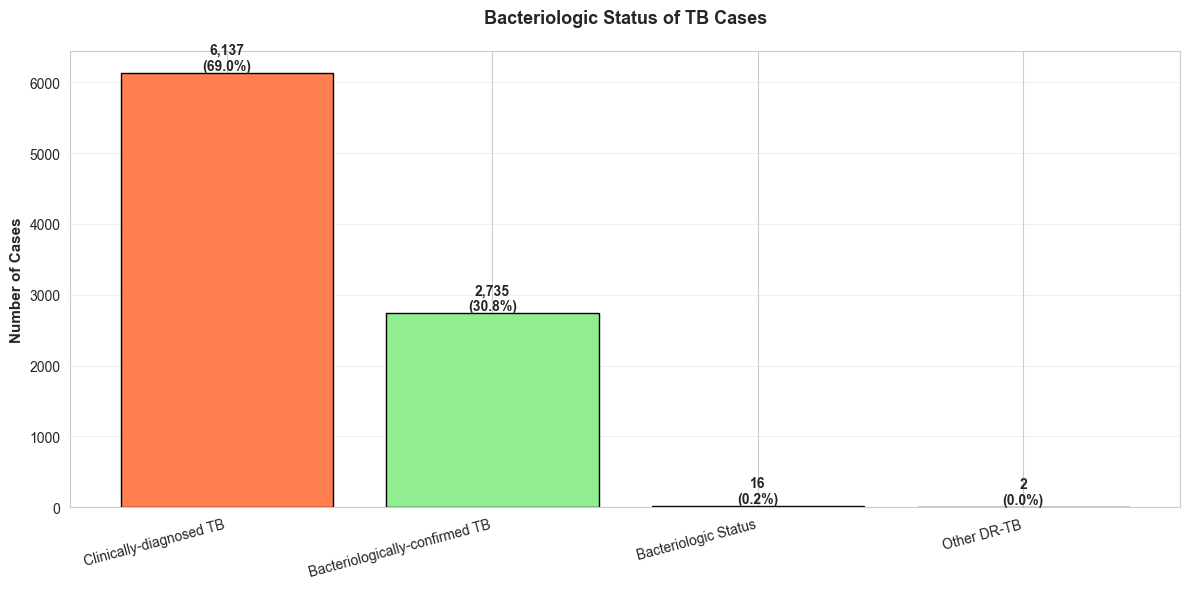

In [26]:
# Bacteriologic status
if 'Bacteriologic Status' in df.columns:
    bact_counts = df['Bacteriologic Status'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.bar(range(len(bact_counts)), bact_counts.values, 
                  color=['coral', 'lightgreen'], edgecolor='black')
    ax.set_xticks(range(len(bact_counts)))
    ax.set_xticklabels(bact_counts.index, rotation=15, ha='right')
    ax.set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
    ax.set_title('Bacteriologic Status of TB Cases', fontsize=13, fontweight='bold', pad=20)
    
    for i, v in enumerate(bact_counts.values):
        ax.text(i, v, f'{v:,}\n({v/bact_counts.sum()*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')
    
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

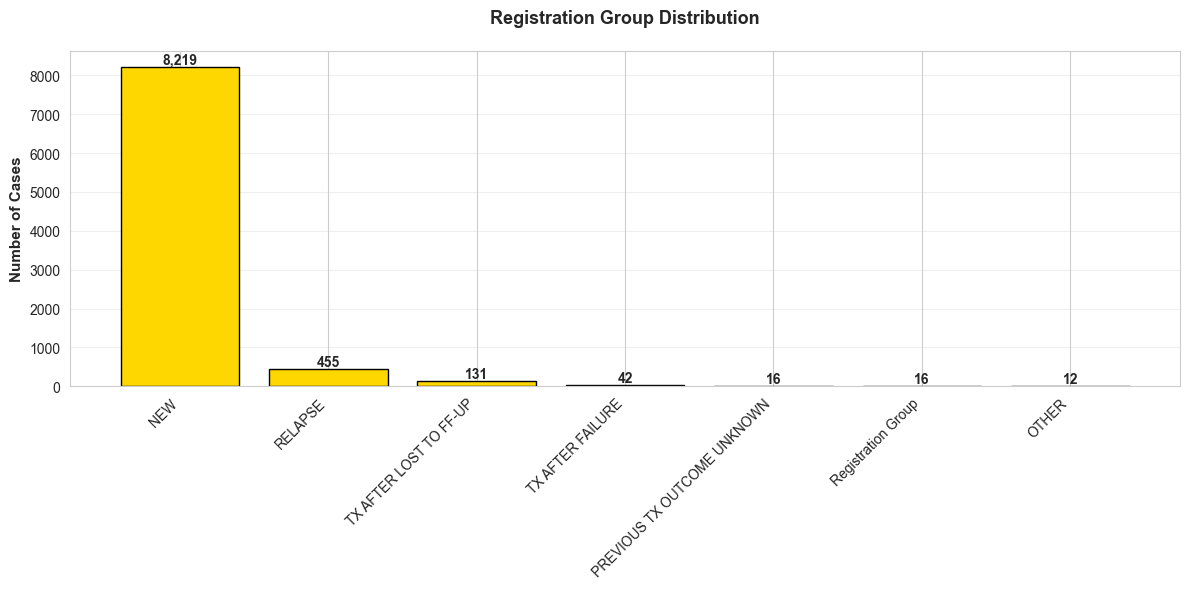

In [27]:
# Registration group distribution
if 'Registration Group' in df.columns:
    reg_counts = df['Registration Group'].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.bar(range(len(reg_counts)), reg_counts.values, color='gold', edgecolor='black')
    ax.set_xticks(range(len(reg_counts)))
    ax.set_xticklabels(reg_counts.index, rotation=45, ha='right')
    ax.set_ylabel('Number of Cases', fontsize=11, fontweight='bold')
    ax.set_title('Registration Group Distribution', fontsize=13, fontweight='bold', pad=20)
    
    for i, v in enumerate(reg_counts.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

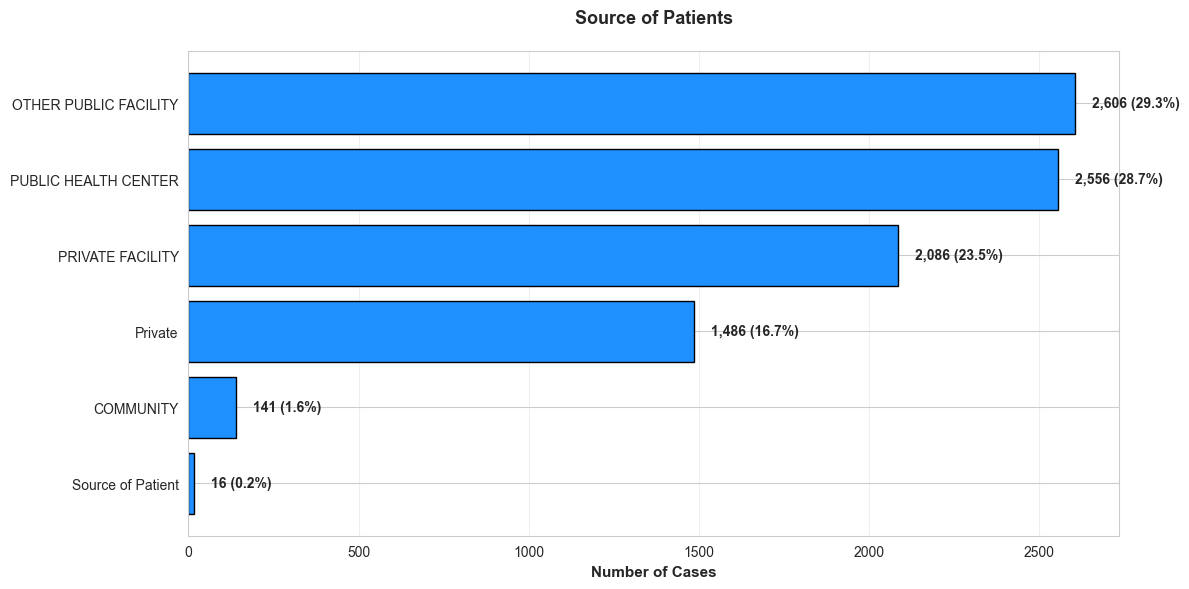

In [28]:
# Patient source analysis
if 'Source of Patient' in df.columns:
    source_counts = df['Source of Patient'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.barh(range(len(source_counts)), source_counts.values, 
                   color='dodgerblue', edgecolor='black')
    ax.set_yticks(range(len(source_counts)))
    ax.set_yticklabels(source_counts.index)
    ax.set_xlabel('Number of Cases', fontsize=11, fontweight='bold')
    ax.set_title('Source of Patients', fontsize=13, fontweight='bold', pad=20)
    ax.invert_yaxis()
    
    for i, v in enumerate(source_counts.values):
        ax.text(v + 50, i, f'{v:,} ({v/source_counts.sum()*100:.1f}%)', 
                va='center', fontweight='bold')
    
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Treatment Outcomes

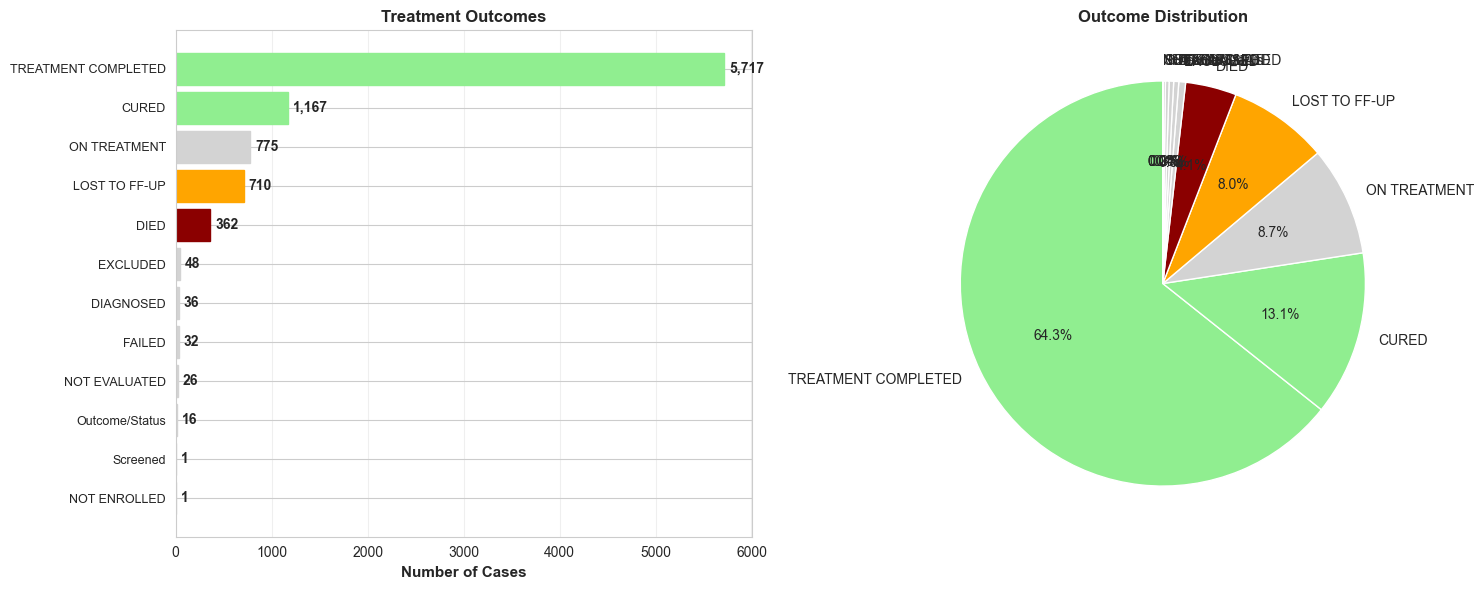

Saved: treatment_outcomes.png


In [29]:
# Overall outcome distribution
if 'Outcome/Status' in df.columns:
    outcome_counts = df['Outcome/Status'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart
    bars = axes[0].barh(range(len(outcome_counts)), outcome_counts.values, edgecolor='black')
    
    # Color code outcomes
    colors = []
    for outcome in outcome_counts.index:
        if outcome in ['CURED', 'TREATMENT COMPLETED']:
            colors.append('lightgreen')
        elif outcome in ['DIED']:
            colors.append('darkred')
        elif outcome in ['LOST TO FF-UP']:
            colors.append('orange')
        else:
            colors.append('lightgray')
    
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    axes[0].set_yticks(range(len(outcome_counts)))
    axes[0].set_yticklabels(outcome_counts.index, fontsize=9)
    axes[0].set_xlabel('Number of Cases', fontsize=11, fontweight='bold')
    axes[0].set_title('Treatment Outcomes', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    
    for i, v in enumerate(outcome_counts.values):
        axes[0].text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
    
    axes[0].grid(axis='x', alpha=0.3)
    
    # Pie chart
    axes[1].pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%',
                startangle=90, colors=colors)
    axes[1].set_title('Outcome Distribution', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('eda_outputs/images/treatment_outcomes.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: treatment_outcomes.png")

In [30]:
# Treatment success rate calculation
if 'Outcome/Status' in df.columns:
    total_with_outcome = df['Outcome/Status'].notna().sum()
    successful = df['Outcome/Status'].isin(['CURED', 'TREATMENT COMPLETED']).sum()
    died = df['Outcome/Status'].eq('DIED').sum()
    lost = df['Outcome/Status'].eq('LOST TO FF-UP').sum()
    
    print("Treatment Outcome Summary:\n")
    print(f"Total cases with outcome: {total_with_outcome:,}")
    print(f"Successful treatment (Cured/Completed): {successful:,} ({successful/total_with_outcome*100:.1f}%)")
    print(f"Died: {died:,} ({died/total_with_outcome*100:.1f}%)")
    print(f"Lost to follow-up: {lost:,} ({lost/total_with_outcome*100:.1f}%)")

Treatment Outcome Summary:

Total cases with outcome: 8,891
Successful treatment (Cured/Completed): 6,884 (77.4%)
Died: 362 (4.1%)
Lost to follow-up: 710 (8.0%)


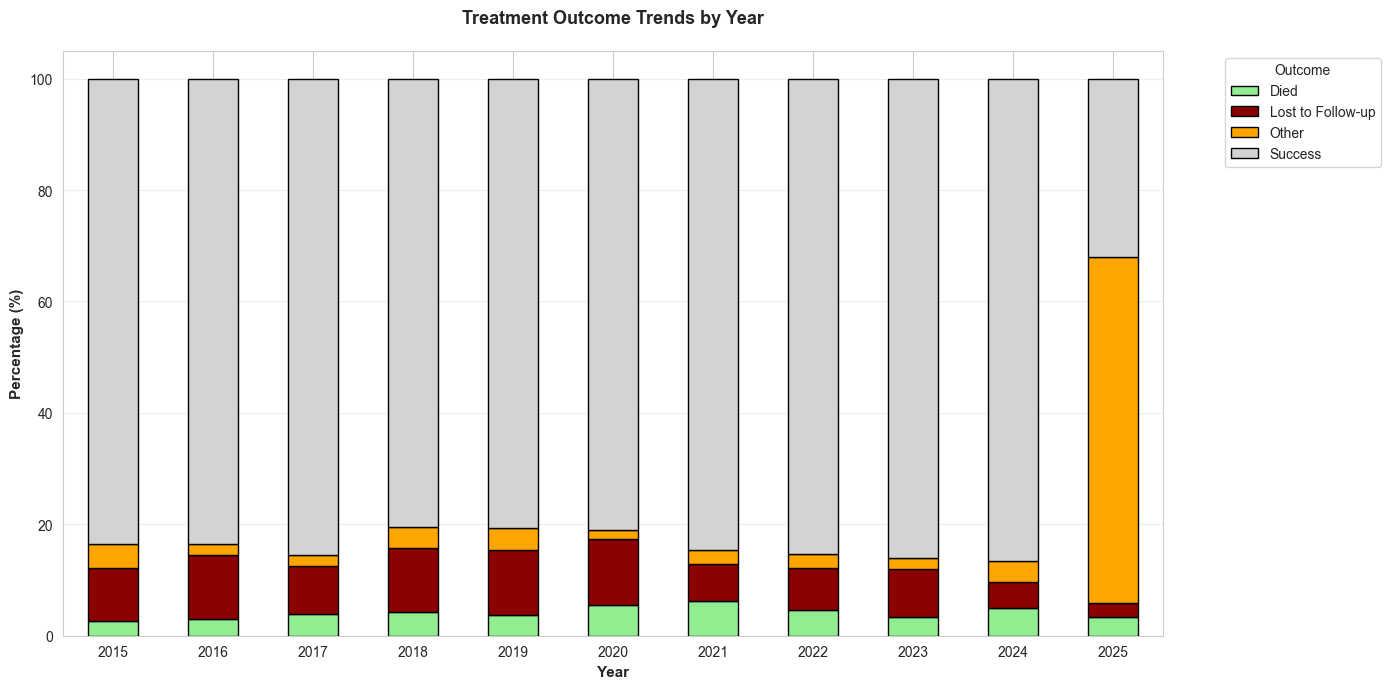

In [31]:
# Outcome trends over years
if 'Outcome/Status' in df.columns:
    # Group outcomes into categories
    df['Outcome_Category'] = df['Outcome/Status'].apply(lambda x: 
        'Success' if x in ['CURED', 'TREATMENT COMPLETED'] else
        'Died' if x == 'DIED' else
        'Lost to Follow-up' if x == 'LOST TO FF-UP' else
        'Other'
    )
    
    outcome_by_year = pd.crosstab(df['Year'], df['Outcome_Category'], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    outcome_by_year.plot(kind='bar', stacked=True, ax=ax, 
                         color=['lightgreen', 'darkred', 'orange', 'lightgray'],
                         edgecolor='black')
    
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_title('Treatment Outcome Trends by Year', fontsize=13, fontweight='bold', pad=20)
    ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Time Interval Analysis


Screening to Diagnosis Statistics:
count    2999.000000
mean        9.709236
std        25.636243
min         0.000000
25%         0.000000
50%         0.000000
75%         8.000000
max       365.000000
Name: Screening_to_Diagnosis, dtype: float64

Diagnosis to Notification Statistics:
count    3419.000000
mean        6.596666
std        15.605197
min         0.000000
25%         0.000000
50%         0.000000
75%         7.000000
max       180.000000
Name: Diagnosis_to_Notification, dtype: float64

Diagnosis to Treatment Statistics:
count    3005.000000
mean        5.755075
std        12.578644
min         0.000000
25%         0.000000
50%         1.000000
75%         6.000000
max       180.000000
Name: Diagnosis_to_Treatment, dtype: float64


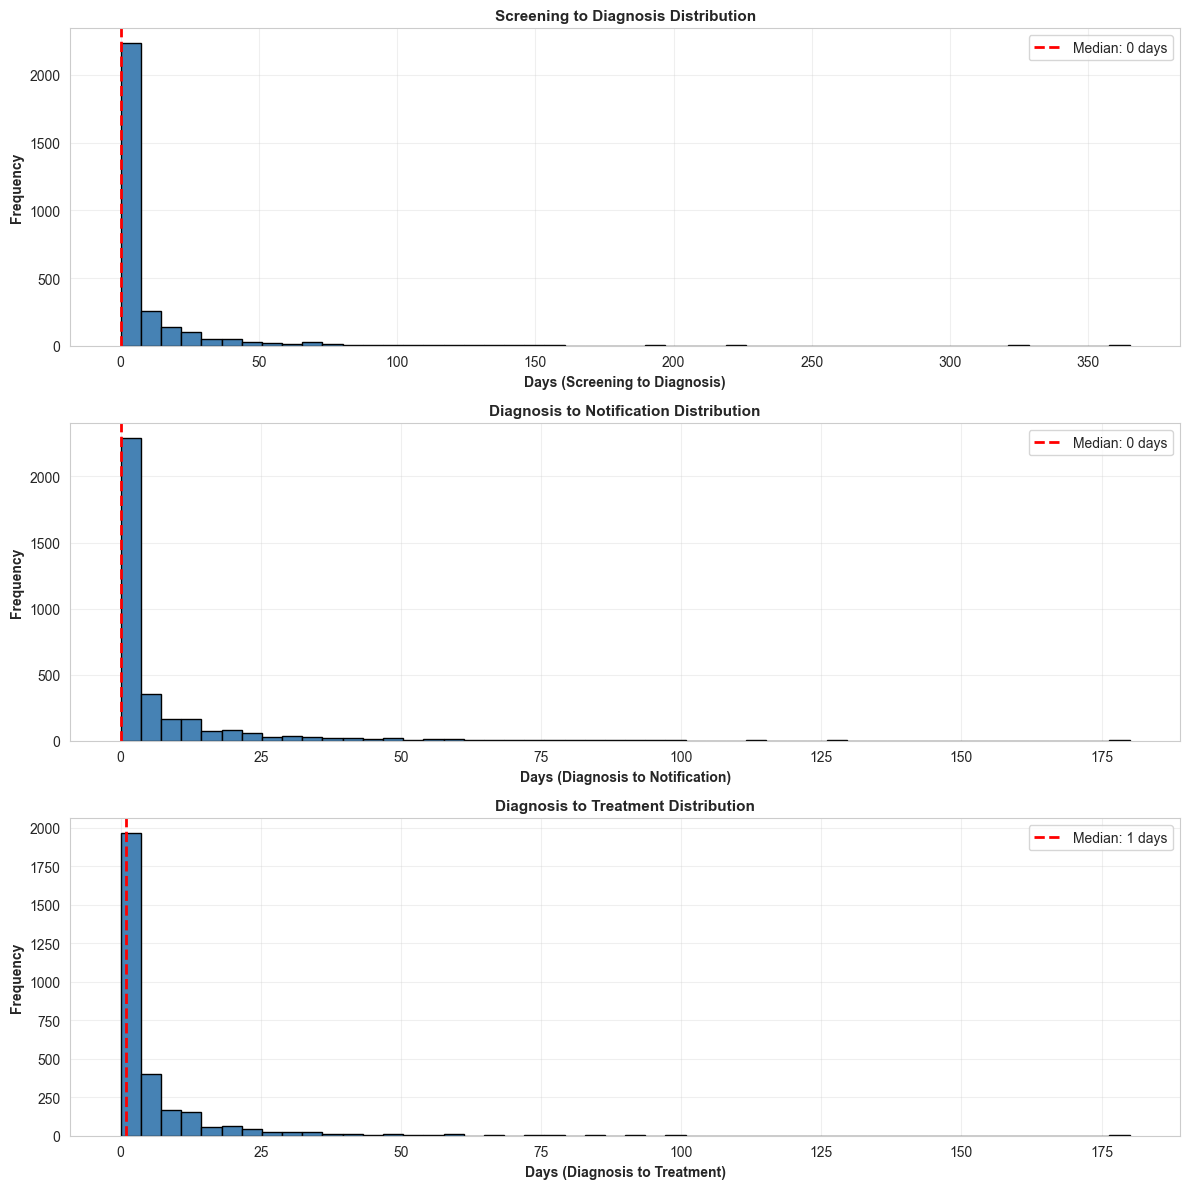

In [32]:
# Calculate time intervals
df['Screening_to_Diagnosis'] = (df['Date of Diagnosis'] - df['Date of Screening']).dt.days
df['Diagnosis_to_Notification'] = (df['Date of Notification'] - df['Date of Diagnosis']).dt.days
df['Diagnosis_to_Treatment'] = (df['Date Started Tx'] - df['Date of Diagnosis']).dt.days

# Filter reasonable values (remove outliers)
time_intervals = [
    ('Screening_to_Diagnosis', 0, 365),
    ('Diagnosis_to_Notification', 0, 180),
    ('Diagnosis_to_Treatment', 0, 180)
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for idx, (interval, min_val, max_val) in enumerate(time_intervals):
    data = df[interval].dropna()
    data = data[(data >= min_val) & (data <= max_val)]
    
    if len(data) > 0:
        axes[idx].hist(data, bins=50, color='steelblue', edgecolor='black')
        axes[idx].set_xlabel(f'Days ({interval.replace("_", " ")})', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontsize=10, fontweight='bold')
        axes[idx].set_title(f'{interval.replace("_", " ")} Distribution', fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)
        
        # Add median line
        median = data.median()
        axes[idx].axvline(median, color='red', linestyle='--', linewidth=2, 
                         label=f'Median: {median:.0f} days')
        axes[idx].legend()
        
        print(f"\n{interval.replace('_', ' ')} Statistics:")
        print(data.describe())

plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [33]:
# Create comprehensive summary
summary = {
    'Total Cases': len(df),
    'Years Covered': f"{df['Year'].min()} - {df['Year'].max()}",
    'Average Cases per Year': f"{len(df) / df['Year'].nunique():.0f}",
    'Male Cases': df['Sex'].eq('M').sum() if 'Sex' in df.columns else 'N/A',
    'Female Cases': df['Sex'].eq('F').sum() if 'Sex' in df.columns else 'N/A',
    'Median Age': f"{df[df['Age_Valid']]['Age_Numeric'].median():.1f} years",
    'Pulmonary TB': df['Anatomical Site'].eq('P').sum() if 'Anatomical Site' in df.columns else 'N/A',
    'Extrapulmonary TB': df['Anatomical Site'].eq('EP').sum() if 'Anatomical Site' in df.columns else 'N/A',
    'Bacteriologically Confirmed': df['Bacteriologic Status'].str.contains('Bacteriologically', na=False).sum() if 'Bacteriologic Status' in df.columns else 'N/A',
    'Treatment Success': df['Outcome/Status'].isin(['CURED', 'TREATMENT COMPLETED']).sum() if 'Outcome/Status' in df.columns else 'N/A',
    'Deaths': df['Outcome/Status'].eq('DIED').sum() if 'Outcome/Status' in df.columns else 'N/A',
    'Lost to Follow-up': df['Outcome/Status'].eq('LOST TO FF-UP').sum() if 'Outcome/Status' in df.columns else 'N/A'
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print("\n" + "="*60)
print("TB CASE NOTIFICATIONS SUMMARY (2015-2025)")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


TB CASE NOTIFICATIONS SUMMARY (2015-2025)
                     Metric       Value
                Total Cases        8939
              Years Covered 2015 - 2025
     Average Cases per Year         813
                 Male Cases        4749
               Female Cases        2640
                 Median Age  42.0 years
               Pulmonary TB        8110
          Extrapulmonary TB         765
Bacteriologically Confirmed        2735
          Treatment Success        6884
                     Deaths         362
          Lost to Follow-up         710


## 10. Data Quality Report

In [34]:
# Export missing data summary to CSV
output_dir = Path('eda_outputs')
output_dir.mkdir(exist_ok=True)

missing_stats.to_csv(output_dir / 'missing_data_summary.csv', index=False)
missing_by_year.to_csv(output_dir / 'missing_data_by_year.csv')

print("\nData quality reports exported to 'eda_outputs/' directory:")
print("  - missing_data_summary.csv")
print("  - missing_data_by_year.csv")


Data quality reports exported to 'outputs/' directory:
  - missing_data_summary.csv
  - missing_data_by_year.csv


In [35]:
# Final data quality assessment
quality_metrics = {
    'Total Records': len(df),
    'Complete Records (all critical fields)': complete_records,
    'Completeness Rate': f"{complete_records/len(df)*100:.1f}%",
    'Records with Missing Age': (~df['Age_Valid']).sum(),
    'Records with Missing Sex': df['Sex'].isna().sum(),
    'Records with Missing Outcome': df['Outcome/Status'].isna().sum(),
    'Records with Missing Dates': df[['Date of Screening', 'Date of Diagnosis', 'Date of Notification']].isna().any(axis=1).sum(),
    'Average Completeness': f"{(1 - df.isna().sum().sum() / (len(df) * len(df.columns)))*100:.1f}%"
}

quality_df = pd.DataFrame(list(quality_metrics.items()), columns=['Quality Metric', 'Value'])

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)
print(quality_df.to_string(index=False))
print("="*60)


DATA QUALITY ASSESSMENT
                        Quality Metric Value
                         Total Records  8939
Complete Records (all critical fields)  7388
                     Completeness Rate 82.6%
              Records with Missing Age  1550
              Records with Missing Sex    50
          Records with Missing Outcome    48
            Records with Missing Dates  5512
                  Average Completeness 82.2%
